In [8]:
# パラメータの更新

In [9]:
# SGD
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr  

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [10]:
# SGDの欠点

In [11]:
# Momentum
import numpy as np

class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.le*grads[key]
            params[key] += self.v[key]

In [12]:
# AdaGradの実装
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.key():
            self.h[key] += grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)


In [13]:
# Adam

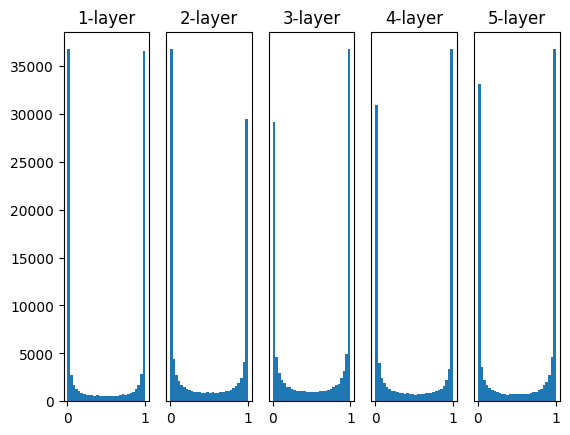

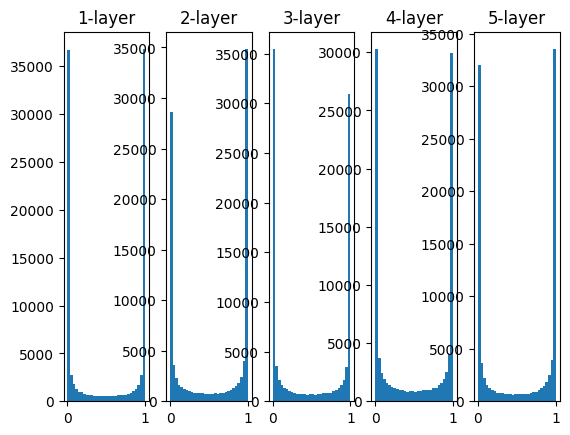

In [ ]:
# 隠れ層のアクティベーション分布
import numpy as np
import matplotlib.pyplot as plt
from weight_init_activation_histogram import activations

rng = np.random.default_rng()

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = rng.standard_normal((1000, 100))
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = rng.standard_normal((node_num, node_num)) * 1

    z = np.dot(x, w)
    a = sigmoid(z)
    activations[i] = a

# ヒストグラムを描画
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))

plt.show()

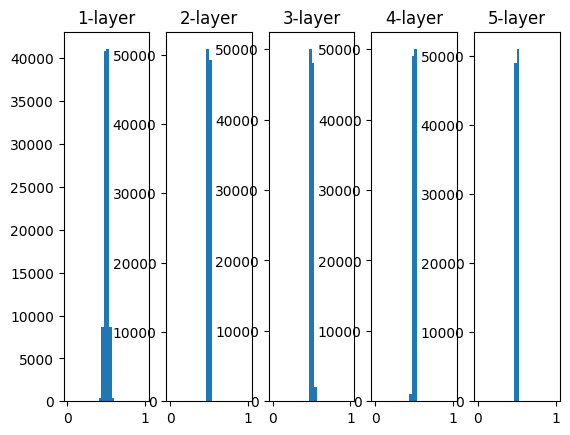

In [16]:
# 重みの設定を変えてみる
import numpy as np
import matplotlib.pyplot as plt
from weight_init_activation_histogram import activations

rng = np.random.default_rng()

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = rng.standard_normal((1000, 100))
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = rng.standard_normal((node_num, node_num)) * 0.01

    z = np.dot(x, w)
    a = sigmoid(z)
    activations[i] = a

# ヒストグラムを描画
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))

plt.show()

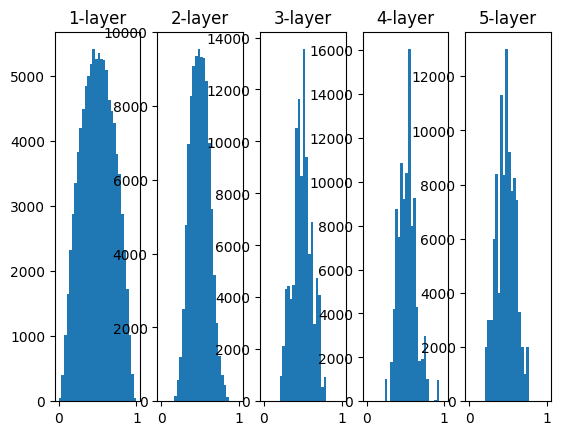

In [17]:
# Xavierの初期値
import numpy as np
import matplotlib.pyplot as plt
from weight_init_activation_histogram import activations

rng = np.random.default_rng()

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = rng.standard_normal((1000, 100))
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = rng.standard_normal((node_num, node_num)) / np.sqrt(node_num)

    z = np.dot(x, w)
    a = sigmoid(z)
    activations[i] = a

# ヒストグラムを描画
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))

plt.show()

In [ ]:
# ReLuの場合の重みの初期値

===========iteration:0===========
std=0.01:2.3025231324790365
Xavier:2.306784909333179
He:2.2996797116113767
===========iteration:100===========
std=0.01:2.301873281611746
Xavier:2.2318927568639433
He:1.571544431345611
===========iteration:200===========
std=0.01:2.301367743076022
Xavier:1.9840176568719885
He:0.7547415819276884
===========iteration:300===========
std=0.01:2.302748109596489
Xavier:1.461900290278682
He:0.5646693079051901
===========iteration:400===========
std=0.01:2.304036208843139
Xavier:0.9893736943690277
He:0.5190070902696401
===========iteration:500===========
std=0.01:2.301419085382347
Xavier:0.6454200842878575
He:0.2979529569292161
===========iteration:600===========
std=0.01:2.2981891770730147
Xavier:0.5740285789000719
He:0.31271290350535413
===========iteration:700===========
std=0.01:2.301345043716652
Xavier:0.6471010946318339
He:0.35159607184296054
===========iteration:800===========
std=0.01:2.304393006692164
Xavier:0.5282071001028921
He:0.36884576476794095
=

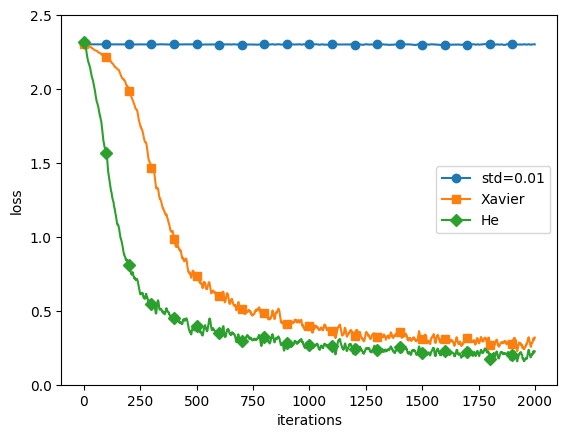

In [18]:
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

============== 1/16 ==============
epoch:0 | 0.094 - 0.103
epoch:1 | 0.097 - 0.129
epoch:2 | 0.097 - 0.165


c:\make-deep-learning-from-scratch\ch06\..\common\layers.py:57: RuntimeWarning: overflow encountered in dot
  out = np.dot(self.x, self.W) + self.b
c:\make-deep-learning-from-scratch\ch06\..\common\layers.py:57: RuntimeWarning: invalid value encountered in dot
  out = np.dot(self.x, self.W) + self.b
c:\make-deep-learning-from-scratch\ch06\..\common\multi_layer_net_extend.py:101: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\make-deep-learning-from-scratch\ch06\..\common\multi_layer_net_extend.py:101: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\make-deep-learning-from-scratch\ch06\..\common\layers.py:63: RuntimeWarning: invalid value encountered in dot
  self.dW = np.dot(self.x.T, dout)


epoch:3 | 0.097 - 0.187
epoch:4 | 0.097 - 0.204
epoch:5 | 0.097 - 0.218
epoch:6 | 0.097 - 0.232
epoch:7 | 0.097 - 0.247
epoch:8 | 0.097 - 0.27
epoch:9 | 0.097 - 0.288
epoch:10 | 0.097 - 0.293
epoch:11 | 0.097 - 0.31
epoch:12 | 0.097 - 0.321
epoch:13 | 0.097 - 0.338
epoch:14 | 0.097 - 0.356
epoch:15 | 0.097 - 0.374
epoch:16 | 0.097 - 0.387
epoch:17 | 0.097 - 0.39
epoch:18 | 0.097 - 0.408
epoch:19 | 0.097 - 0.422
============== 2/16 ==============
epoch:0 | 0.117 - 0.113
epoch:1 | 0.097 - 0.097


C:\Users\yamaw\AppData\Local\Temp\ipykernel_56952\4124623709.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


epoch:2 | 0.097 - 0.112
epoch:3 | 0.097 - 0.127
epoch:4 | 0.097 - 0.135
epoch:5 | 0.097 - 0.155
epoch:6 | 0.097 - 0.182
epoch:7 | 0.097 - 0.2
epoch:8 | 0.097 - 0.218
epoch:9 | 0.097 - 0.251
epoch:10 | 0.097 - 0.279
epoch:11 | 0.097 - 0.305
epoch:12 | 0.097 - 0.334
epoch:13 | 0.097 - 0.352
epoch:14 | 0.097 - 0.371
epoch:15 | 0.097 - 0.378
epoch:16 | 0.097 - 0.402
epoch:17 | 0.097 - 0.426
epoch:18 | 0.097 - 0.427
epoch:19 | 0.097 - 0.452
============== 3/16 ==============
epoch:0 | 0.18 - 0.08
epoch:1 | 0.41 - 0.107
epoch:2 | 0.584 - 0.136
epoch:3 | 0.666 - 0.188
epoch:4 | 0.739 - 0.222
epoch:5 | 0.825 - 0.273
epoch:6 | 0.85 - 0.323
epoch:7 | 0.892 - 0.359
epoch:8 | 0.923 - 0.394
epoch:9 | 0.955 - 0.446
epoch:10 | 0.969 - 0.466
epoch:11 | 0.98 - 0.492
epoch:12 | 0.988 - 0.525
epoch:13 | 0.99 - 0.551
epoch:14 | 0.991 - 0.568
epoch:15 | 0.994 - 0.578
epoch:16 | 0.997 - 0.61
epoch:17 | 0.998 - 0.634
epoch:18 | 0.999 - 0.644
epoch:19 | 0.999 - 0.666
============== 4/16 ==============
epoch:0

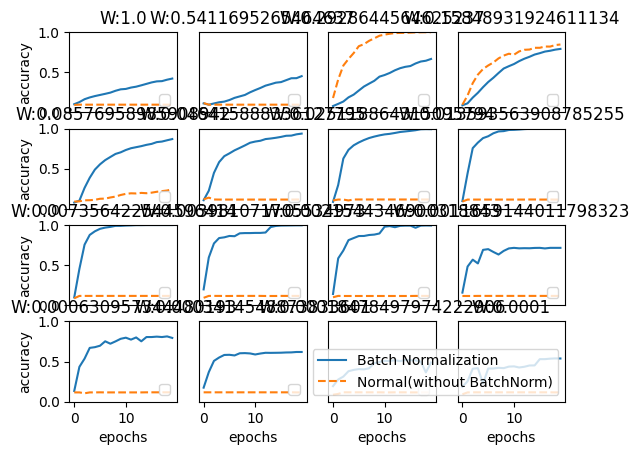

In [22]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.show()

epoch:0, train acc:0.11333333333333333, test acc:0.0979
epoch:1, train acc:0.11333333333333333, test acc:0.0985
epoch:2, train acc:0.11333333333333333, test acc:0.0986
epoch:3, train acc:0.11666666666666667, test acc:0.0989
epoch:4, train acc:0.11666666666666667, test acc:0.0996
epoch:5, train acc:0.11666666666666667, test acc:0.1001
epoch:6, train acc:0.12666666666666668, test acc:0.1022
epoch:7, train acc:0.13, test acc:0.1023
epoch:8, train acc:0.13666666666666666, test acc:0.1044
epoch:9, train acc:0.13666666666666666, test acc:0.1055
epoch:10, train acc:0.14, test acc:0.1061
epoch:11, train acc:0.15333333333333332, test acc:0.1108
epoch:12, train acc:0.16333333333333333, test acc:0.1137
epoch:13, train acc:0.17666666666666667, test acc:0.117
epoch:14, train acc:0.18333333333333332, test acc:0.1171
epoch:15, train acc:0.19666666666666666, test acc:0.1243
epoch:16, train acc:0.20333333333333334, test acc:0.1251
epoch:17, train acc:0.22333333333333333, test acc:0.1309
epoch:18, train

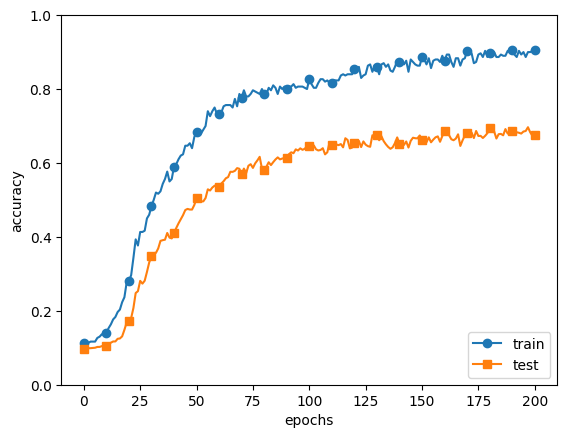

In [23]:
# 過学習
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.07333333333333333, test acc:0.0897
epoch:1, train acc:0.06666666666666667, test acc:0.0883
epoch:2, train acc:0.09, test acc:0.0939
epoch:3, train acc:0.12333333333333334, test acc:0.1042
epoch:4, train acc:0.16333333333333333, test acc:0.1201
epoch:5, train acc:0.20333333333333334, test acc:0.1431
epoch:6, train acc:0.22333333333333333, test acc:0.1635
epoch:7, train acc:0.28, test acc:0.1972
epoch:8, train acc:0.30333333333333334, test acc:0.2183
epoch:9, train acc:0.33666666666666667, test acc:0.2416
epoch:10, train acc:0.3566666666666667, test acc:0.2578
epoch:11, train acc:0.39, test acc:0.2816
epoch:12, train acc:0.4266666666666667, test acc:0.304
epoch:13, train acc:0.44, test acc:0.317
epoch:14, train acc:0.45, test acc:0.332
epoch:15, train acc:0.44666666666666666, test acc:0.3363
epoch:16, train acc:0.44666666666666666, test acc:0.3398
epoch:17, train acc:0.4666666666666667, test acc:0.3501
epoch:18, train acc:0.47, test acc:0.3526
epoch:19, train acc:0.4

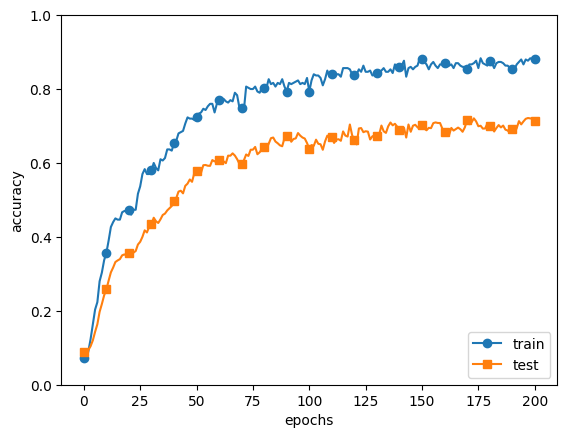

In [24]:
# Weight decay
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [25]:
# Dropout
class Dropout:
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask

train loss:2.292010551990637
=== epoch:1, train acc:0.1, test acc:0.0933 ===
train loss:2.321944999060303
train loss:2.337168712853274
train loss:2.2778658041569106
=== epoch:2, train acc:0.09333333333333334, test acc:0.0943 ===
train loss:2.3385223177400833
train loss:2.3008422990487447
train loss:2.30696459339028
=== epoch:3, train acc:0.09, test acc:0.0969 ===
train loss:2.3117949669053814
train loss:2.2961994213573
train loss:2.306423081949937
=== epoch:4, train acc:0.09666666666666666, test acc:0.0996 ===
train loss:2.2791254439174375
train loss:2.325079244443694
train loss:2.2876115488357254
=== epoch:5, train acc:0.11, test acc:0.1006 ===
train loss:2.303140279800654
train loss:2.2915252915889206
train loss:2.2904788323376444
=== epoch:6, train acc:0.11333333333333333, test acc:0.1034 ===
train loss:2.278604509977284
train loss:2.322742616595065
train loss:2.294243154470665
=== epoch:7, train acc:0.12333333333333334, test acc:0.1056 ===
train loss:2.2713740867945713
train loss:2

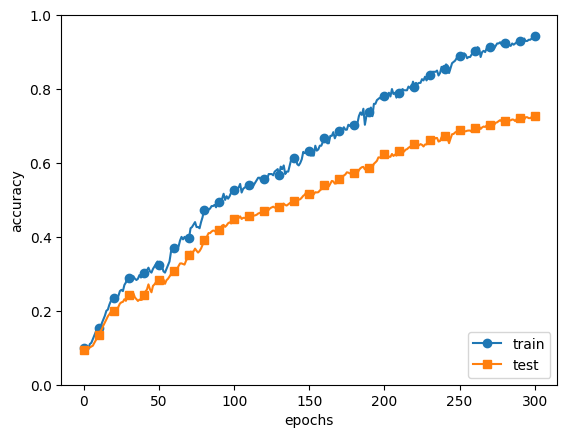

In [27]:
# coding: utf-8
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.15
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [28]:
# ハイパーパラメータの検証
# 検証データ

In [29]:
(x_train, t_train), (x_test, t_test) = load_mnist()

# 訓練データをシャッフル
validation_rete = 0.20
validation_num = int(x_train.shape[0] * validation_rete)

x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]

val acc:0.08 | lr:0.0003354714831252147, weight decay:1.1520712678980004e-08
val acc:0.14 | lr:3.479216089590066e-05, weight decay:3.6562571349448417e-06
val acc:0.15 | lr:1.1278194307702269e-05, weight decay:2.500464645078274e-06
val acc:0.13 | lr:8.971188649707675e-05, weight decay:3.152833024208987e-06
val acc:0.75 | lr:0.009463461198221135, weight decay:1.9255261723829713e-05
val acc:0.09 | lr:6.766453170502274e-06, weight decay:2.3274606786949456e-07
val acc:0.05 | lr:6.3020037924052944e-06, weight decay:7.836499816809377e-07
val acc:0.1 | lr:6.024578342185637e-06, weight decay:1.8883772179757672e-08
val acc:0.11 | lr:6.436894476460597e-06, weight decay:7.62084520743531e-05
val acc:0.15 | lr:0.00027547136880171264, weight decay:7.668976049317936e-07
val acc:0.19 | lr:0.00043644552890656756, weight decay:3.3684024938633636e-06
val acc:0.13 | lr:1.5013015938494733e-06, weight decay:1.8463450044434987e-08
val acc:0.14 | lr:6.0765647099576626e-05, weight decay:9.459464260928475e-08
va

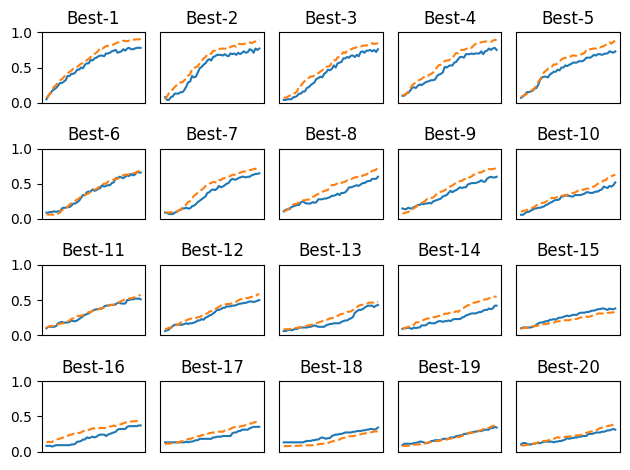

In [31]:
# ハイパーパラメータの最適化の実装
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 高速化のため訓練データの削減
x_train = x_train[:500]
t_train = t_train[:500]

# 検証データの分離
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# ハイパーパラメータのランダム探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 探索したハイパーパラメータの範囲を指定===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# グラフの描画========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break
plt.tight_layout()
plt.show()